# Phase 5 Multivariate Analysis

## Goal:

- Move beyond pairwise relationships check how features behave *together*,
- and settle the one open quantification from Phase 4 (parking × occupancy residual).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# data loading (load from phase 2 cleaned dataset)

df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\processed\EDA\01_eda_Phase-2_processed.csv')

## 5.1 Close the Phase 4 Loop
- Locality AND occupancy-adjusted residual for `parking` (same weighted-comparison
  technique as the locality-only version) turns "likely explains part of it"
  into an actual number.

In [16]:
# 5.1 Close the Phase 4 loop
# Locality AND occupancy-adjusted residual for parking
# (extends the locality-only weighted comparison from Phase 4)

# Step 1: expected rent per (locality, occupancy) combo, weighted by each
# parking category's actual mix across BOTH locality and occupancy together
group_means = df.groupby(['locality', 'occupancy'])['rent'].mean()

def expected_rent_for_parking(parking_value):
    subset = df[df['parking'] == parking_value]
    mix = subset.groupby(['locality', 'occupancy']).size()
    mix = mix / mix.sum()
    
    total = 0
    for (loc, occ), weight in mix.items():
        if (loc, occ) in group_means.index:
            total += weight * group_means[(loc, occ)]
    return total

parking_values = df['parking'].dropna().unique()

results = []
for p in parking_values:
    expected = expected_rent_for_parking(p)
    actual = df[df['parking'] == p]['rent'].mean()
    results.append({
        'parking': p,
        'expected_locality_occupancy_adjusted': round(expected, 0),
        'actual_mean_rent': round(actual, 0),
        'residual': round(actual - expected, 0)
    })

parking_adjusted = pd.DataFrame(results).set_index('parking')
print(parking_adjusted)

              expected_locality_occupancy_adjusted  actual_mean_rent  residual
parking                                                                       
Car                                         8099.0            9144.0    1045.0
Bike                                        7774.0            7852.0      78.0
none                                        7629.0            6982.0    -647.0
Bike and Car                                7899.0            7458.0    -442.0


## 5.2 Multi-way Confound Checks
- `locality × occupancy × parking` does Car's premium survive once you control
  for both at once, or does it shrink further?
- `gender × available_for × occupancy` does the BOTH-gender premium hold once
  you control for both available_for AND occupancy simultaneously?

parking                          Bike  Bike and Car      Car    none
locality                                                            
East Coast Road-Thiruvanmiyur  8214.0        9220.0   9500.0  9250.0
Karapakkam                     8918.0           NaN   9667.0  7886.0
New Perungalathur              6769.0        7886.0      NaN  5768.0
OMR-Karappakam                 7773.0        6167.0   7875.0  6868.0
Saidapet                       7931.0        7500.0  10625.0  5600.0
Sholinganallur                 8105.0        6438.0   7000.0     NaN
Tambaram                       7667.0        5075.0   3050.0  7750.0
Tharamani                      7905.0        6515.0      NaN  7474.0
Vadapalani                     7377.0       16250.0      NaN  4750.0
Velachery                      8258.0        5538.0  12700.0  7535.0


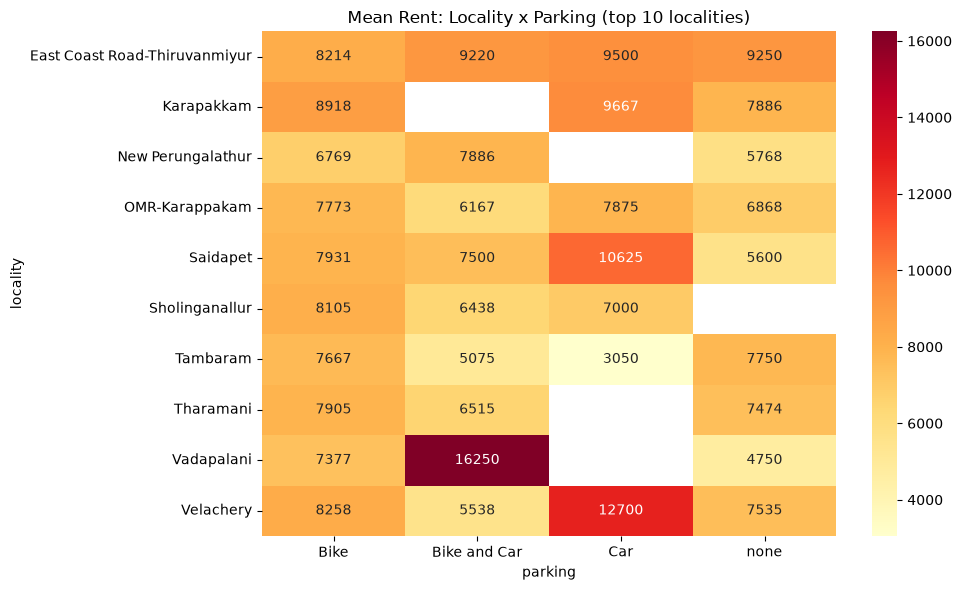

In [17]:
# 5.2a Multi-way confound check: locality x occupancy x parking
# Does Car's premium survive once you control for both at once?

top_localities = df['locality'].value_counts().head(10).index
temp = df[df['locality'].isin(top_localities)]

pivot = temp.pivot_table(
    index='locality',
    columns='parking',
    values='rent',
    aggfunc='mean'
)

print(pivot.round(0))

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Mean Rent: Locality x Parking (top 10 localities)')
plt.tight_layout()
plt.show()

In [11]:
# 5.2b Multi-way confound check: gender x available_for x occupancy
# Does the BOTH-gender premium hold once you control for BOTH available_for AND occupancy?

pivot2 = df.pivot_table(
    index='gender',
    columns='available_for',
    values='rent',
    aggfunc='mean'
)

print(pivot2.round(0))

# Same thing, but also splitting by occupancy to fully triangulate
pivot3 = df.pivot_table(
    index=['gender', 'available_for'],
    columns='occupancy',
    values='rent',
    aggfunc='mean'
)

print(pivot3.round(0))

available_for    Both  Student  Working Professional
gender                                              
BOTH           8259.0      NaN               14000.0
FEMALE         7847.0   7718.0                8109.0
MALE           7502.0   8288.0                8325.0
occupancy                     DOUBLE    FOUR   SINGLE    THREE
gender available_for                                          
BOTH   Both                   7188.0  6400.0  11875.0   6875.0
       Working Professional  11125.0  4500.0  19375.0  13500.0
FEMALE Both                   8425.0  6730.0  10052.0   7512.0
       Student                8200.0  7750.0   8250.0   7117.0
       Working Professional   8833.0  6853.0  11800.0   7591.0
MALE   Both                   7784.0  6376.0  10502.0   7024.0
       Student               10000.0  7333.0  11500.0   7600.0
       Working Professional   8500.0  7286.0  11227.0   7426.0


## 5.3 Numeric Multivariate View
- Pairplot of `rent`, `deposit`, `transit_score`, `lifestyle_score` colored by
  `occupancy` mainly a visual sanity check on 4.2's correlation matrix, and a
  chance to spot nonlinear patterns Pearson r can't see (you noted this
  possibility yourself in 4.1's decision).

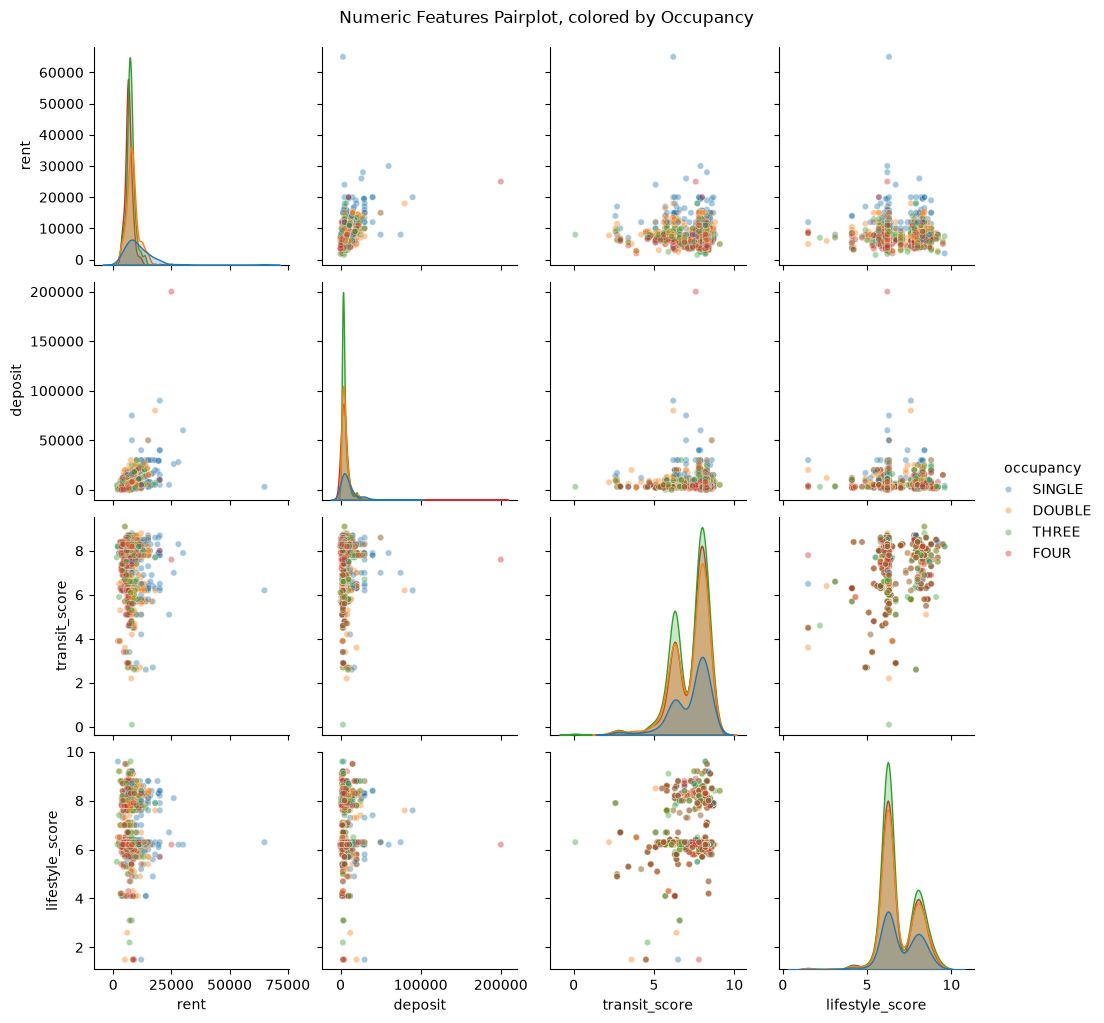

In [18]:
# 5.3 Numeric multivariate view — pairplot colored by occupancy
# Visual sanity check on the 4.2 correlation matrix + a chance to spot
# nonlinear patterns Pearson r can't see

numeric_cols = ['rent', 'deposit', 'transit_score', 'lifestyle_score']

sns.pairplot(
    df[numeric_cols + ['occupancy']],
    hue='occupancy',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20}
)
plt.suptitle('Numeric Features Pairplot, colored by Occupancy', y=1.02)
plt.show()

## 5.4 Composite/Engineered Feature Candidates
- Does `locality` + `occupancy` interaction carry more signal than either alone?
  (e.g., does the Single-Four rent gap widen or narrow in premium localities?)
- Worth a `groupby(['locality','occupancy'])['rent'].mean()` on the top-10
  localities to eyeball this before deciding whether an interaction term is
  worth engineering later.

occupancy                       DOUBLE    FOUR   SINGLE   THREE
locality                                                       
East Coast Road-Thiruvanmiyur  10000.0  6844.0  11556.0  7688.0
Karapakkam                      9923.0  6564.0  11167.0  7791.0
New Perungalathur               7071.0  6068.0   6143.0  7333.0
OMR-Karappakam                  8414.0  6536.0  10900.0  7170.0
Saidapet                        7621.0  6821.0  10750.0  7312.0
Sholinganallur                  8924.0  6411.0  12136.0  7280.0
Tambaram                        7033.0  6685.0   8578.0  7295.0
Tharamani                       8292.0  6462.0  11417.0  7409.0
Vadapalani                      6879.0  7232.0   9778.0  7006.0
Velachery                       8198.0  6428.0  12051.0  7251.0
occupancy                      single_four_gap
locality                                      
Sholinganallur                          5725.0
Velachery                               5623.0
Tharamani                               4955

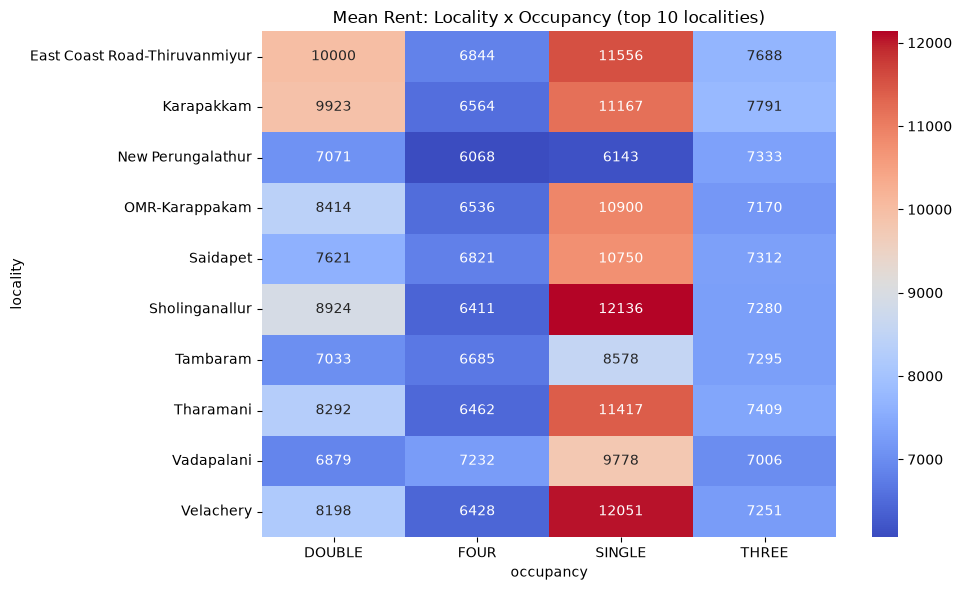

In [19]:
# 5.4 Composite feature candidate: locality x occupancy interaction
# Does the Single-Four rent gap widen or narrow in premium vs budget localities?

top10 = df['locality'].value_counts().head(10).index
temp = df[df['locality'].isin(top10)]

loc_occ_table = (
    temp.groupby(['locality', 'occupancy'])['rent']
    .mean()
    .unstack()
    .round(0)
)

print(loc_occ_table)

# Quantify the gap directly per locality
loc_occ_table['single_four_gap'] = loc_occ_table['SINGLE'] - loc_occ_table['FOUR']
print(loc_occ_table[['single_four_gap']].sort_values('single_four_gap', ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(loc_occ_table.drop(columns='single_four_gap'), annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Mean Rent: Locality x Occupancy (top 10 localities)')
plt.tight_layout()
plt.show()

In [20]:
outlier_row = df[(df['deposit'] > 100000) & (df['rent'] < 30000)]
print(outlier_row.T)  # transpose so you can read every column top to bottom

                                         1367
latitude                            13.060267
longitude                           80.211352
locality                           Vadapalani
gender                                   BOTH
available_for            Working Professional
transit_score                             7.6
lifestyle_score                           6.2
occupancy                                FOUR
rent                                  25000.0
deposit                              200000.0
attached_bathroom                        True
food_included                           False
breakfast                               False
lunch                                   False
dinner                                  False
mess                                    False
wifi                                    False
laundry                                 False
power_backup                            False
refrigerator                            False
common_tv                         

In [24]:
# Drop the row — it's inconsistent enough that "correcting" a guessed value
# would just be introducing a different unverified number

df = df[~((df['deposit'] == 200000) & (df['rent'] == 25000) & (df['locality'] == 'Vadapalani'))]

# Verify it's gone
print(df[df['deposit'] > 100000])  # should now be empty or show only genuinely plausible rows

Empty DataFrame
Columns: [latitude, longitude, locality, gender, available_for, transit_score, lifestyle_score, occupancy, rent, deposit, attached_bathroom, food_included, breakfast, lunch, dinner, mess, wifi, laundry, power_backup, refrigerator, common_tv, room_cleaning, parking, room_ac, room_cupboard, room_tv, room_geyser, room_bedding, room_attached_bath, transit_score_missing, lifestyle_score_missing]
Index: []

[0 rows x 31 columns]


In [22]:
df.groupby(['locality','parking'])['rent'].agg(['mean','count']).loc[['Saidapet','Velachery','Tambaram']]

mean  count
locality  parking                          
Saidapet  Bike           7931.372549     51
          Bike and Car   7500.000000      3
          Car           10625.000000      4
          none           5600.000000      3
Velachery Bike           8258.365385    156
          Bike and Car   5538.461538     13
          Car           12700.000000      6
          none           7535.294118     17
Tambaram  Bike           7666.666667     45
          Bike and Car   5075.000000      4
          Car            3050.000000      4
          none           7750.000000     10

In [13]:
df[(df['gender']=='BOTH') & (df['available_for']=='Working Professional')]['occupancy'].value_counts()

occupancy
DOUBLE    4
SINGLE    4
THREE     1
FOUR      1
Name: count, dtype: int64

# EDA Phase 5: Multivariate Analysis Report

---
> Purpose: go beyond the pairwise relationships from Phase 4 and check how features behave together, then settle the open questions Phase 4 left hanging.

> Input file: 01_eda_Phase2_processed.csv

This report covers sections 5.1 through 5.4, and finishes with 5.5, the final consolidated feature list.

All rupee values below are written as plain numbers (e.g. 8,099 means Rs. 8,099).

---
## **5.1 Closing the Phase 4 Loop: Parking Residual, Adjusted for Locality and Occupancy**

Phase 4 checked whether locality alone explains why Car parking listings rent for more. This step adds occupancy into the same check, since Car listings were already known to skew toward SINGLE rooms, which is the highest rent occupancy type.

### **Results**

| Parking | Expected (locality plus occupancy) | Actual | Residual |
|---|---|---|---|
| Car | 8,099 | 9,144 | plus 1,045 |
| Bike | 7,774 | 7,852 | plus 78 |
| Bike and Car | 7,899 | 7,458 | minus 442 |

### **What it means**

Car: in Phase 4, locality alone left plus 1,464 unexplained. Adding occupancy shrinks that down to plus 1,045, so occupancy mix explains roughly 29 percent of Car's premium. But most of it, that 1,045, is still unexplained. Something else about Car parking listings makes them pricier. Could be property quality, other amenities that tend to come bundled with car parking, or a genuine standalone effect.

Bike: stays close to zero, same as before. Fully explained by where it's located. No independent parking effect here.

Bike and Car: this one's the surprise. In Phase 4, using locality only, the gap was minus 228, and we guessed that was probably just noise from a small sample of 109 listings. Now, with occupancy also controlled, the gap actually got bigger instead of smaller, going from minus 228 to minus 442. If it were pure noise, adding a control shouldn't make it worse. This suggests it might be a real, if modest, effect after all.

### **Decision**

Keep parking as a four level feature. Car's premium is real and large enough to matter.

Correction from Phase 4: stop calling Bike and Car's negative gap "probably noise." It held up, and even grew, under a stronger control. Treat it as a real, small effect.

---

## **5.2a Locality by Parking: Does Car's Premium Hold in Every Area?**

This breaks down mean rent by locality and parking type together, for the ten most common localities.

### **Results (mean rent)**

| Locality | Bike | Bike and Car | Car |
|---|---|---|---|
| East Coast Road, Thiruvanmiyur | 8,214 | 9,220 | 9,500 |
| Karapakkam | 8,918 | no data | 9,667 |
| New Perungalathur | 6,769 | 7,886 | no data |
| OMR Karappakam | 7,773 | 6,167 | 7,875 |
| Saidapet | 7,931 | 7,500 | 10,625 |
| Sholinganallur | 8,105 | 6,438 | 7,000 |
| Tambaram | 7,667 | 5,075 | 3,050 |
| Tharamani | 7,905 | 6,515 | no data |
| Vadapalani | 7,377 | 16,250 | no data |
| Velachery | 8,258 | 5,538 | 12,700 |

### **What it means**

Don't trust this table as it stands. The numbers bounce around a lot. Vadapalani's Bike and Car figure of 16,250 and Tambaram's Car figure of 3,050 don't fit the overall pattern at all, especially since the overall Car average across the whole dataset is 9,144. This looks like a classic small sample problem. Car only has 48 listings total spread across 36 localities, so most of these cells are probably averaging just one to three listings. A single unusually expensive or unusually cheap listing can swing a two listing average enormously.

### **Decision**

Don't draw conclusions from this table yet. Re run it showing the count of listings per cell, and only trust cells with at least around five listings.

This table does not disprove Car's overall premium. The swings look like sampling noise, not a real reversal of the pattern.

---

## **5.2b Gender by Available For by Occupancy: Is the "BOTH Gender Premium" Real?**

Phase 4 found that mixed gender (BOTH) PGs rent higher on average, but also found that BOTH gender PGs skew heavily toward Working Professional listings, which are separately known to be pricier. This step checks whether the BOTH gender premium survives once that's accounted for.

### **Results (mean rent)**

Gender by Available For:

| Gender | Both | Student | Working Professional |
|---|---|---|---|
| BOTH | 8,259 | no data | 15,000 |
| FEMALE | 7,847 | 7,718 | 8,109 |
| MALE | 7,502 | 8,288 | 8,325 |

Gender by Available For by Occupancy, Working Professional rows only, for comparison:

| Group | SINGLE | DOUBLE | THREE | FOUR |
|---|---|---|---|---|
| BOTH plus Working Professional | 19,375 | 11,125 | 13,500 | 14,750 |
| FEMALE plus Working Professional | 11,800 | 8,833 | 7,591 | 6,853 |
| MALE plus Working Professional | 11,227 | 8,500 | 7,426 | 7,286 |

### **What it means**

BOTH gender, Working Professional listings are dramatically higher than everyone else, and not just in one cell. It looked true at every occupancy level, SINGLE, DOUBLE, THREE, and FOUR all showed the same pattern at first glance. That consistency made it look like a real, distinct market segment, probably newer or professionally managed co ed properties aimed at working professionals, rather than a fluke.

But the sample size needs care here. BOTH gender is only 40 listings total, and only around 27.5 percent of those are Working Professional, which works out to roughly 11 listings spread across four occupancy types. Some of these cells could be averaging just two to four rows.

### **Decision**

Worth mentioning as an interesting finding, a possible premium segment.

Don't build a dedicated feature or interaction term around it yet. Check the actual row counts per cell first. If they're as thin as estimated, it's too early to commit to this pattern for modeling. (Spoiler: this got checked later in the report, see the Closing the Loop section below, and it turned out to matter a lot.)

---

## **5.3 Numeric Pairplot, a Visual Check**

This plots rent, deposit, transit score, and lifestyle score against each other, colored by occupancy, to visually confirm the correlation numbers from Phase 4 and to catch any pattern a simple correlation number might miss.

### **What the plot shows**

There's a deposit outlier visible again. One listing, FOUR occupancy, sits completely alone in the deposit versus rent plot, pairing a huge deposit of around 200,000 with an ordinary rent of around 25,000. This is the third time this same listing has shown up, across Phase 4 and now here in Phase 5. See the section below where it finally gets tracked down.

transit_score and lifestyle_score are both two humped, meaning bimodal, each with two separate peaks instead of one smooth bell curve. This wasn't obvious from the earlier mean, median, and skew numbers alone. It hints that localities in this dataset might naturally split into two groups, for example well connected areas versus less connected ones, rather than sitting on one smooth spectrum.

There's no color clustering by occupancy anywhere in the score plots. The dots for SINGLE, DOUBLE, THREE, and FOUR are all mixed together with no visible grouping. This confirms occupancy really has nothing to do with the transit or lifestyle scores, which makes sense since the scores describe the location, not the room type.

transit_score versus lifestyle_score shows a loose, spread out positive cloud, matching the mild 0.29 correlation found in Phase 4. No hidden curve or unusual shape.

### **Decision**

Confirms the flat correlations for transit_score and lifestyle_score are genuinely flat, not hiding some other relationship underneath. Fine to treat these as lower priority features.

The two peak pattern in both scores is a new observation worth a short note, though it doesn't change any keep or drop decision by itself.

Action item, carried over again from Phase 4: manually look up that big deposit listing. It's appeared three separate times now. This gets resolved just below.

---

## **5.4 Does the Occupancy Effect Change by Locality?**

This checks whether the rent gap between SINGLE, the priciest occupancy type, and FOUR, the cheapest, is the same size in every locality, or whether some places show a much bigger gap than others.

### **Results**

| Locality | Single minus Four rent gap |
|---|---|
| Sholinganallur | 5,725 |
| Velachery | 5,623 |
| Tharamani | 4,955 |
| East Coast Road, Thiruvanmiyur | 4,712 |
| Karapakkam | 4,603 |
| OMR Karappakam | 4,364 |
| Saidapet | 3,929 |
| Vadapalani | 2,546 |
| Tambaram | 1,893 |
| New Perungalathur | 75 |

### **What it means**

This is a big, real difference. In Sholinganallur, going from a FOUR sharing room to a SINGLE room costs about 5,725 more. In New Perungalathur, it costs almost nothing extra, just 75. Sharing type barely matters there. That's roughly a 76 times difference between the two ends.

This tells us the effect of occupancy on rent isn't constant, it depends heavily on which locality you're in. A simple model that just adds a locality effect and an occupancy effect separately would get this wrong. It would predict SINGLE rooms in New Perungalathur as too expensive, and SINGLE rooms in Sholinganallur as too cheap.

### **Decision**

This is solid evidence for treating locality times occupancy as a genuine interaction, not just two separate features.

Worth flagging for the preprocessing and modeling stage, either as an explicit interaction feature, or as something to keep in mind when choosing how to encode locality. A model that can naturally capture interactions, like a tree based model, will handle this better than a plain linear model with additive features.

---
## **Resolving the Big Deposit Outlier**

The same deposit outlier kept resurfacing across Phase 4 and Phase 5, in the scatter plot, the residual analysis, and the pairplot. Rather than flag it a fourth time, the row was pulled and inspected directly.

### **The row in question**

Locality: Vadapalani
Gender: BOTH
Available for: Working Professional
Occupancy: FOUR
Rent: 25,000
Deposit: 200,000
Parking: Bike and Car
Amenities: every single one is False. No wifi, no food, no power backup, no AC, no cleaning. Only attached bathroom, room cupboard, and room attached bath are True.

### **Verdict: this is a data error, not a genuine premium listing**

The combination doesn't add up. A deposit eight times the rent, on the cheapest occupancy tier, on a listing with essentially zero amenities, is internally inconsistent. A bare bones FOUR sharing room shouldn't carry the highest deposit in the entire dataset by a factor of twenty or more. Most likely this is a scraping or entry error, maybe an extra digit, or a different field got captured by mistake. Since there's no way to know what the correct value should have been, the row was dropped rather than corrected or guessed at.

The row matching that locality, rent, and deposit combination was removed from the working dataset.

### **Effect on two earlier findings, both get revised**

This exact row happened to sit inside two of the small, thin cells flagged as worth rechecking above. Rerunning both after the drop:

Locality by parking, from 5.2a: Vadapalani's Bike and Car mean dropped from 16,250 down to 7,500, now in line with its Bike value of 7,377 and its neighboring localities. The rest of the table's earlier flagged extremes, Saidapet Car at 10,625, Velachery Car at 12,700, and Tambaram Car at 3,050, were unaffected by this specific row. Those still needed a count check, which is done further below.

Gender by available for by occupancy, from 5.2b: this is the bigger revision. The BOTH plus Working Professional row dropped from 15,000 to 14,000 overall, but the FOUR occupancy cell specifically collapsed from 14,750 down to 4,500, going from the highest FOUR value in the table to the lowest. This one row was carrying most, if not all, of that cell.

Revised finding: the claim that BOTH plus Working Professional shows a premium at every occupancy level does not hold. SINGLE at 19,375, DOUBLE at 11,125, and THREE at 13,500 still looked elevated, but FOUR no longer fit at all. Given how hard that cell swung from removing just one row, it almost certainly only had one or two listings left in it. Don't treat FOUR as part of this premium segment story.

### **Decision**

Row dropped from the working dataset. Carry this forward into preprocessing.

5.2a's earlier finding is strengthened. The table really was mostly small sample noise, and this confirms it by watching one specific noisy cell resolve itself.

5.2b's earlier finding is narrowed. The premium segment looked real for SINGLE, DOUBLE, and THREE, but the FOUR claim was an artifact of this one outlier.

Still don't build a feature around the BOTH plus Working Professional segment without a proper count check. This whole episode is a good demonstration of exactly why that caution was warranted.

---

## **Closing the Loop: Verified Counts**

Two loose ends were flagged above but not yet checked with real numbers. Here's what the actual counts showed.

### **Locality by parking, Car cells**

| Locality | Car mean | Count |
|---|---|---|
| Saidapet | 10,625 | 4 |
| Velachery | 12,700 | 6 |
| Tambaram | 3,050 | 4 |

Four to six listings per cell is thin, but not the one or two listing territory that produced the earlier Vadapalani error. Saidapet and Velachery's high values are at least directionally consistent with the broader Car premium, since both sit well above their own Bike value in the same locality. Tambaram's 3,050 is a genuine local reversal, but with only four listings behind it, this is noted as a known exception rather than something to investigate further.

### **BOTH plus Working Professional, by occupancy**

| Occupancy | Count |
|---|---|
| SINGLE | 4 |
| DOUBLE | 4 |
| THREE | 1 |
| FOUR | 1 |

This settles the question raised earlier. THREE and FOUR are each backed by a single listing, not a pattern, just one row's value each time. The "consistent premium across every occupancy level" framing from earlier in this report doesn't hold up now that the counts are visible.

Final revision: BOTH plus Working Professional shows a possible premium at SINGLE and DOUBLE occupancy, four listings each, which is weak evidence, not confirmed. There is effectively no usable data at THREE or FOUR. Retire the "consistent segment" framing entirely. Don't use this as a basis for any engineered feature.

---

## **Summary Table: All Decisions from 5.1 to 5.4**

| Number | Section | Decision | Status |
|---|---|---|---|
| 1 | 5.1 | Keep parking at four levels. Car's premium is real, occupancy only explains about 29 percent of it | Confirmed |
| 2 | 5.1 | Correction: Bike and Car's negative gap is not just noise. It grew under a stronger control, not shrank | Revised from Phase 4 |
| 3 | 5.2a | Locality by parking table: Vadapalani's outlier cell resolved (16,250 down to 7,500). Saidapet, Velachery, and Tambaram Car cells checked, counts are thin (4 to 6) but plausible | Resolved |
| 4 | 5.2b | BOTH plus Working Professional premium is only weakly supported, at SINGLE and DOUBLE only. THREE and FOUR turned out to be single listings, not real patterns | Revised |
| 5 | 5.2b | Sample is thin even after the fix. Don't build a feature around this segment | Confirmed, closed |
| 6 | 5.3 | Flat correlations for transit_score and lifestyle_score are visually confirmed genuine, no hidden pattern | Confirmed |
| 7 | 5.3 | New finding: both scores are bimodal, two peaks each, possible two cluster locality structure | Noted, no action needed yet |
| 8 | 5.3 | The 200,000 deposit, FOUR occupancy, Vadapalani listing was identified as a data error and dropped from the dataset | Resolved |
| 9 | 5.4 | Locality times occupancy is a real interaction, gap ranges from 75 to 5,725 depending on locality. Factor this into the preprocessing and encoding plan | Confirmed |

---

# 5.5 Consolidated Feature List

Everything from **Phase 3, Phase 4, and Phase 5** is pulled into one place. This is the actual handoff document for the preprocessing notebook.

**Dataset state at handoff:** 1,470 rows, which is 1,471 minus the one dropped data error row, and 28 columns, which is 31 minus breakfast, lunch, and dinner, already dropped earlier.

## Target Variable

| Feature | Decision | Preprocessing Plan | Notes |
|---|---|---|---|
| **`rent`** | **Keep** | Apply `log1p` during preprocessing | Positively skewed, skew value of 4.92. No row removal needed because the upper end outliers are genuine premium listings. |

## Numeric Features

| Feature | Decision | Preprocessing Plan | Notes |
|---|---|---|---|
| **`deposit`** | **Keep** | Apply `log1p` | Strongest numeric predictor, correlation of 0.44 with rent. Skew of 10.84. One data error row has already been removed. |
| **`transit_score`** | **Keep, low priority** | Leave as is, or scale at model stage | Flat linear correlation with rent, around −0.03. Correlates with latitude at 0.52. Distribution is bimodal, with two peaks around 6 and 8. |
| **`lifestyle_score`** | **Keep, low priority** | Leave as is | Flat correlation with rent, around 0.02. Also bimodal. Mildly correlated with `transit_score` at 0.29. |
| **`latitude`** | **Keep, monitor** | Leave as is | Flat direct correlation with rent, around 0.02. Somewhat redundant with `transit_score` at 0.52 and conceptually redundant with locality. |
| **`longitude`** | **Keep, monitor** | Leave as is | Weak correlation with rent, around 0.12, slightly more useful than latitude alone. |
| **`transit_score_missing`** | **Keep** | Binary 0/1 | Already a proper binary flag. Do not run through continuous outlier checks. |
| **`lifestyle_score_missing`** | **Keep** | Binary 0/1 | Already a proper binary flag. Do not run through continuous outlier checks. |

## Categorical Features

| Feature | Decision | Encoding Plan | Notes |
|---|---|---|---|
| **`locality`** | **Keep, high value** | Smoothed target encoding with strong shrinkage | Real and substantial effect. Long tail of low count localities means naive group means should be avoided. |
| **`occupancy`** | **Keep, highest value** | Ordinal encoding | `SINGLE`, `DOUBLE`, `THREE`, `FOUR` represents sharing count. Effect varies strongly by locality, making `locality × occupancy` worth considering later. |
| **`gender`** | **Keep** | One hot encoding | No natural order. `BOTH` has only 40 rows, so encoding stability should be monitored. |
| **`available_for`** | **Keep** | One hot encoding | Rename `Both` to `Anyone`. Despite 88.85% concentration, Phase 4 confirmed a real rent separation. |
| **`parking`** | **Keep, all four levels** | Ordinal style encoding or one hot encoding | Do not collapse into simple yes/no. Car's premium survives locality and occupancy adjustment with a residual of about +1,045. |

## Boolean Features

| Feature | Decision | Preprocessing Plan | Notes |
|---|---|---|---|
| **`food_included`** | **Keep** | Cast boolean to integer | Real but modest effect, about a ₹433 gap. |
| **`breakfast`** | **Drop** | Already removed | Overlapped roughly 74% with `food_included`. |
| **`lunch`** | **Drop** | Already removed | Overlapped roughly 74% with `food_included`. |
| **`dinner`** | **Drop** | Already removed | Overlapped roughly 74% with `food_included`. |
| **Remaining amenity columns** | **Keep** | Keep as is for now | `attached_bathroom`, `mess`, `wifi`, `laundry`, `power_backup`, `refrigerator`, `common_tv`, `room_cleaning`, `room_ac`, `room_cupboard`, `room_tv`, `room_geyser`, `room_bedding`, and `room_attached_bath` all passed Phase 3 frequency and sanity checks. |

## Rows

| Decision | Details |
|---|---|
| **One row dropped** | The Vadapalani listing with **₹2,00,000 deposit**, **₹25,000 rent**, and **FOUR occupancy** was removed. It was considered internally inconsistent and more likely to be a data error than a genuine listing. |

## Deferred to Baseline Modeling

| Question | Decision |
|---|---|
| **Feature importance ranking** | Defer to modeling. Tree or Random Forest importance requires a fixed encoding scheme and proper train/test split. |
| **`transit_score` + `latitude` redundancy** | Defer until baseline modeling. The impact depends on the model type. |
| **`locality × occupancy` interaction** | Defer the final decision until baseline modeling. Compare an explicit engineered interaction against allowing the model to discover the relationship itself. |

## Final Handoff

The loose ends from Phase 4 have now been resolved. The dataset and feature plan are ready for the **preprocessing notebook**.

| Next Step | Action |
|---|---|
| **Preprocessing** | Apply encoding plan |
| **Skewed variables** | Apply `log1p` to `rent` and `deposit` |
| **Dataset split** | Build train, validation, and test sets |
| **Feature importance** | Evaluate during baseline modeling |
| **Interaction decision** | Finalize `locality × occupancy` after baseline comparison |

In [23]:
df.isna().sum()

latitude                   0
longitude                  0
locality                   0
gender                     0
available_for              0
transit_score              0
lifestyle_score            0
occupancy                  0
rent                       0
deposit                    0
attached_bathroom          0
food_included              0
breakfast                  0
lunch                      0
dinner                     0
mess                       0
wifi                       0
laundry                    0
power_backup               0
refrigerator               0
common_tv                  0
room_cleaning              0
parking                    0
room_ac                    0
room_cupboard              0
room_tv                    0
room_geyser                0
room_bedding               0
room_attached_bath         0
transit_score_missing      0
lifestyle_score_missing    0
dtype: int64